### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

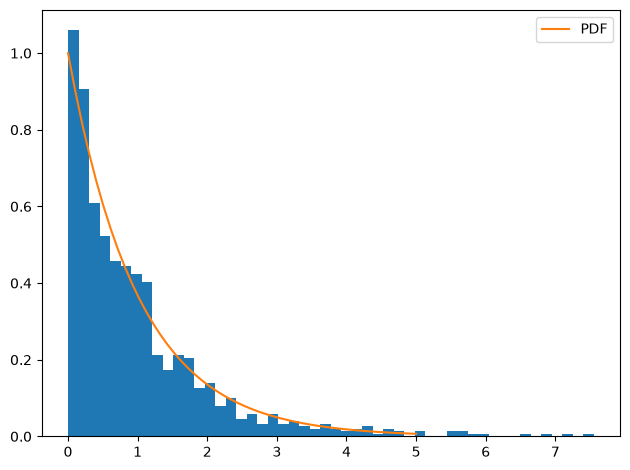

In [ ]:
# Genero i valori con una distribuzione gamma
dist = sp.stats.gamma(1)
sample = dist.rvs(size = 1000)

# Traccio l'istogramma
plt.hist(sample, bins = 50, density = True)
x= np.linspace(0,5)
plt.plot(x, dist.pdf(x), label='PDF')
plt.legend()
plt.tight_layout()
plt.show()


Parametro di forma stimato:
 0.896972443975042


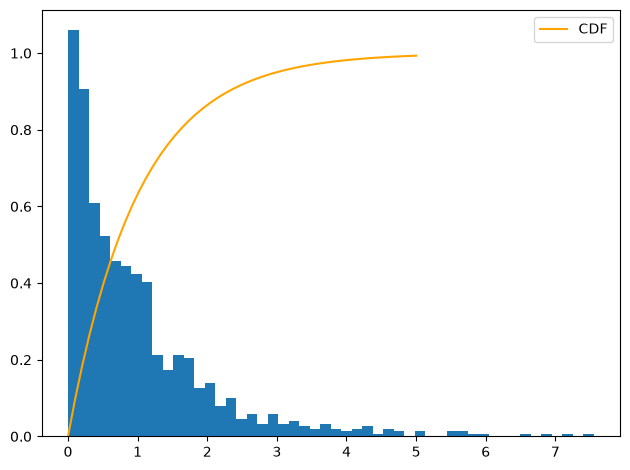


 Varianza teorica:  1.0

 Varianza del campione:  1.1327028993710417


In [22]:
#Stima del parametro di forma del campione
print('Parametro di forma stimato:\n',sp.stats.gamma.fit(sample)[0])

#Funzione di distribuzione cumulativa
plt.hist(sample, bins = 50, density = True)
plt.plot(x, dist.cdf(x), label='CDF', color = 'orange')
plt.legend()
plt.tight_layout()
plt.show()

#Varianza
var_teo = dist.var()
var_sam = sample.var()
print('\n Varianza teorica: ', var_teo)
print('\n Varianza del campione: ', var_sam)

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE

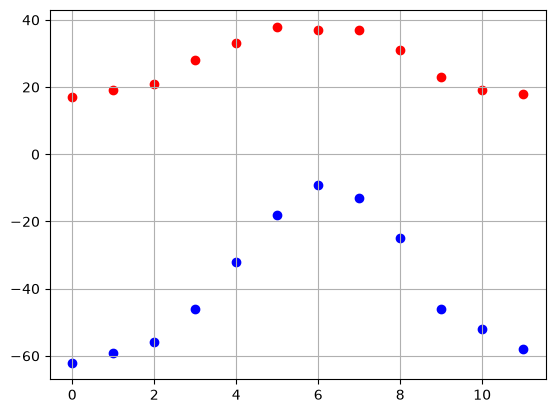

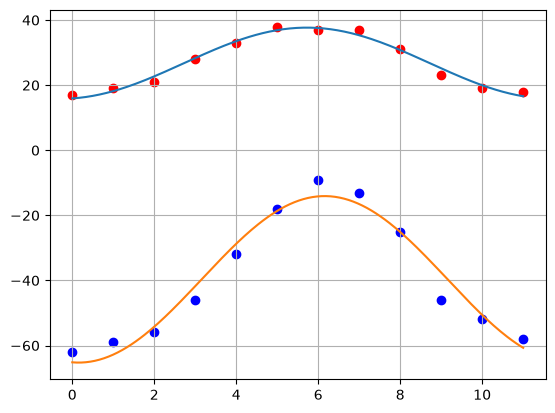

MAE e RMSE per temp_max:  1.0458509746862148 1.1946466156624667
MAE e RMSE per temp_min:  3.185078655611503 3.831099569192342


In [64]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt

# Definisco un asse temporale e osservo il grafico
mesi = np.arange(12)
plt.scatter(x=mesi,y= temp_max, color='red')
plt.scatter(x=mesi,y=temp_min, color='blue')
plt.grid()
plt.show()

#Dal grafico deduco che mi serviranno due fit periodici
def sin(x, a,b,c):
    return c + a*np.sin((x+b)*2*np.pi/12)

par_max, _ = sp.optimize.curve_fit(sin, mesi, temp_max)

par_min, _ = sp.optimize.curve_fit(sin, mesi, temp_min)

x_plot = np.linspace(0, 11, 200)

plt.plot(x_plot, sin(x_plot, *par_max))
plt.scatter(mesi,y= temp_max, color='red')
plt.plot(x_plot, sin(x_plot, *par_min))
plt.scatter(mesi,y=temp_min, color='blue')
plt.grid()
plt.show()

#Resta da calcolare il mae e l'rmse

pred_max = sin(mesi, *par_max)
pred_min = sin(mesi, *par_min)

# temp_max
mae_max = np.mean(np.abs(temp_max - pred_max))
rmse_max = np.sqrt(np.mean((temp_max - pred_max) ** 2))

# temp_min
mae_min = np.mean(np.abs(temp_min - pred_min))
rmse_min = np.sqrt(np.mean((temp_min - pred_min) ** 2))

#stampo
print('MAE e RMSE per temp_max: ', mae_max, rmse_max)
print('MAE e RMSE per temp_min: ', mae_min, rmse_min)


### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

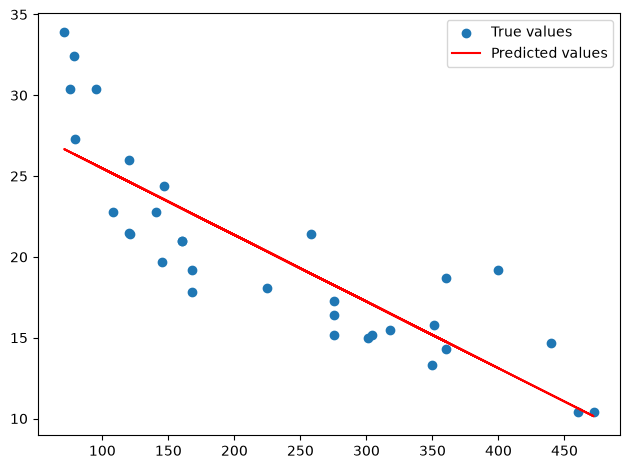

In [65]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df

#Pulisco il dataframe
df.dropna()
df.drop_duplicates()

#Calcolo il modello con scipy
x= df['disp']
y= df['mpg']
slope, intercept, *_ = sp.stats.linregress(x,y)

#quindi trovo
y_pred = slope*x + intercept

plt.scatter(x, y, label = 'True values')
plt.plot(x, y_pred, label = 'Predicted values', color='red')
plt.legend()
plt.tight_layout()
plt.show()